# HW01: physical activity and hormone levels

Доработанная версия: ручные расчеты ANOVA, проверка через `statsmodels`, диагностика и дополнительные сравнения.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
physical_activity = pd.read_csv("data/physical_activity_data.csv")
hormones = pd.read_csv("data/hormone_levels_data.csv")

physical_activity.columns = ["age", "steps"]
hormones.columns = ["age", "measurement_time", "hormone_level"]

physical_activity = physical_activity.dropna().copy()
hormones = hormones.dropna().copy()

physical_activity.head(), hormones.head()

(   age      steps
 0   63  7431.4979
 1   20 10666.2419
 2   46  5215.2322
 3   52  9051.5772
 4   56  7176.1349,
    age  measurement_time  hormone_level
 0   48                11        68.8919
 1   36                22        85.2144
 2   48                11        63.6690
 3   30                 8        76.4220
 4   21                15        45.1365)

In [3]:
physical_activity_summary = physical_activity.describe().T
hormones_summary = hormones.describe().T

physical_activity_summary, hormones_summary

(         count      mean       std       min       25%       50%        75%  \
 age   200.0000   41.3900   14.5484   18.0000   29.0000   41.0000    54.0000   
 steps 200.0000 9655.5071 2376.2440 1623.0372 7998.1034 9564.2344 11302.1884   
 
              max  
 age      65.0000  
 steps 15798.2173  ,
                      count    mean     std     min     25%     50%     75%  \
 age              8400.0000 41.6137 13.8096 18.0000 30.0000 42.0000 54.0000   
 measurement_time 8400.0000 14.0054  4.8913  6.0000 10.0000 14.0000 18.0000   
 hormone_level    8400.0000 69.5119 11.3318 40.1652 61.1289 68.2369 77.1395   
 
                       max  
 age               65.0000  
 measurement_time  22.0000  
 hormone_level    107.0948  )

## Задача 1

Проверяем, различается ли среднее число шагов между возрастными группами.

In [4]:
age_labels = ["G1", "G2", "G3", "G4"]
physical_activity["age_group"] = pd.qcut(physical_activity["age"], q=4, labels=age_labels)

age_group_summary = physical_activity.groupby("age_group", observed=True).agg(
    n=("steps", "size"),
    age_min=("age", "min"),
    age_max=("age", "max"),
    mean_steps=("steps", "mean"),
    median_steps=("steps", "median"),
    std_steps=("steps", "std")
)

age_group_summary

,n,age_min,age_max,mean_steps,median_steps,std_steps
age_group,,,,,,
G1,54,18,29,11645.9235,11391.0829,1617.1549
G2,47,30,41,10201.3822,10022.3263,2027.5844
G3,50,42,54,9093.9811,9178.3121,1784.3647
G4,49,55,65,7511.3783,7718.8609,1887.2292


In [5]:
y = physical_activity["steps"]
grand_mean = y.mean()
grouped = physical_activity.groupby("age_group", observed=True)["steps"]

n_total = len(physical_activity)
k_groups = physical_activity["age_group"].nunique()
group_sizes = grouped.size()
group_means = grouped.mean()

ss_between = float((group_sizes * (group_means - grand_mean) ** 2).sum())
ss_within = float(((y - physical_activity.groupby("age_group", observed=True)["steps"].transform("mean")) ** 2).sum())
ss_total = float(((y - grand_mean) ** 2).sum())

df_between = k_groups - 1
df_within = n_total - k_groups
df_total = n_total - 1

ms_between = ss_between / df_between
ms_within = ss_within / df_within
f_value = ms_between / ms_within
p_value = st.f.sf(f_value, df_between, df_within)
eta_squared = ss_between / ss_total
omega_squared = (ss_between - df_between * ms_within) / (ss_total + ms_within)

manual_anova_oneway = pd.DataFrame(
    {
        "SS": [ss_between, ss_within, ss_total],
        "df": [df_between, df_within, df_total],
        "MS": [ms_between, ms_within, np.nan],
        "F": [f_value, np.nan, np.nan],
        "p_value": [p_value, np.nan, np.nan],
    },
    index=["Between groups", "Within groups", "Total"]
)

manual_anova_oneway.round(5)

,SS,df,MS,F,p_value
Between groups,468972645.5460,3,156324215.1820,46.8002,0.0000
Within groups,654687949.6836,196,3340244.6412,NaN,NaN
Total,1123660595.2296,199,NaN,NaN,NaN


In [6]:
model_oneway = smf.ols("steps ~ C(age_group)", data=physical_activity).fit()
statsmodels_anova_oneway = anova_lm(model_oneway, typ=2)
residuals_oneway = model_oneway.resid

diagnostics_oneway = pd.DataFrame(
    {
        "test": ["Shapiro-Wilk residual normality", "Levene equal variances"],
        "statistic": [
            st.shapiro(residuals_oneway).statistic,
            st.levene(*[part["steps"].to_numpy() for _, part in physical_activity.groupby("age_group", observed=True)]).statistic,
        ],
        "p_value": [
            st.shapiro(residuals_oneway).pvalue,
            st.levene(*[part["steps"].to_numpy() for _, part in physical_activity.groupby("age_group", observed=True)]).pvalue,
        ],
    }
)

effect_sizes_oneway = pd.DataFrame(
    {
        "metric": ["eta_squared", "omega_squared"],
        "value": [eta_squared, omega_squared],
    }
)

statsmodels_anova_oneway.round(5), diagnostics_oneway.round(5), effect_sizes_oneway.round(5)

(                     sum_sq       df       F  PR(>F)
 C(age_group) 468972645.5460   3.0000 46.8002  0.0000
 Residual     654687949.6836 196.0000     NaN     NaN,
                               test  statistic  p_value
 0  Shapiro-Wilk residual normality     0.9948   0.7128
 1           Levene equal variances     1.3107   0.2721,
           metric  value
 0    eta_squared 0.4174
 1  omega_squared 0.4072)

In [7]:
tukey_steps = pairwise_tukeyhsd(
    endog=physical_activity["steps"],
    groups=physical_activity["age_group"],
    alpha=0.05
)

tukey_steps_table = pd.DataFrame(
    data=tukey_steps.summary().data[1:],
    columns=tukey_steps.summary().data[0]
)

tukey_steps_table

,group1,group2,meandiff,p-adj,lower,upper,reject
0,G1,G2,-1444.5413,0.0006,-2389.2680,-499.8146,True
1,G1,G3,-2551.9424,0.0000,-3481.3926,-1622.4922,True
2,G1,G4,-4134.5452,0.0000,-5068.9069,-3200.1835,True
3,G2,G3,-1107.4011,0.0169,-2069.5522,-145.2500,True
4,G2,G4,-2690.0039,0.0000,-3656.9004,-1723.1074,True
5,G3,G4,-1582.6028,0.0002,-2534.5785,-630.6270,True


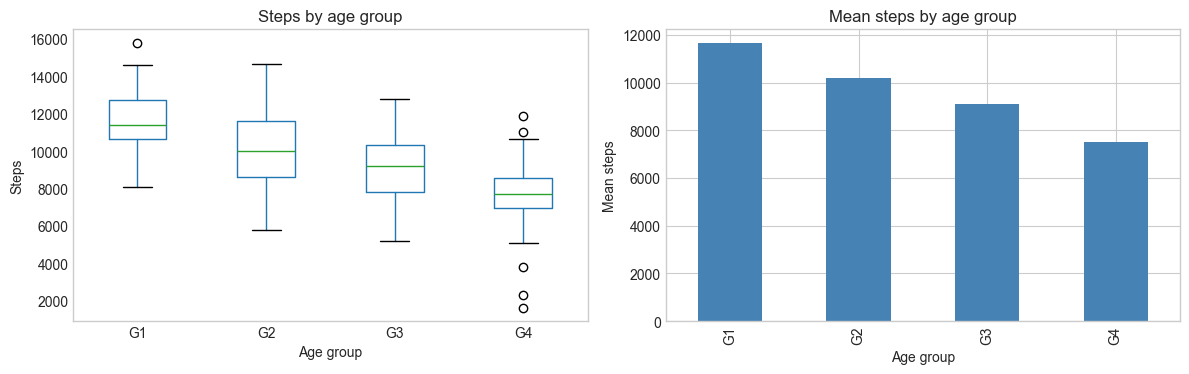

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

physical_activity.boxplot(column="steps", by="age_group", ax=axes[0], grid=False)
axes[0].set_title("Steps by age group")
axes[0].set_xlabel("Age group")
axes[0].set_ylabel("Steps")

age_group_summary["mean_steps"].plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Mean steps by age group")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Mean steps")

fig.suptitle("")
plt.tight_layout()
plt.show()

Вывод: группы по возрасту статистически различаются по среднему числу шагов. Дополнительно проверены размер эффекта, предпосылки и парные различия Tukey.

## Задача 2

Двухфакторный ANOVA: возрастная группа, время измерения и их взаимодействие.

In [9]:
hormones = hormones[(hormones["measurement_time"] >= 6) & (hormones["measurement_time"] <= 22)].copy()

age_labels = ["A1", "A2", "A3", "A4"]
time_labels = ["T1", "T2", "T3", "T4"]

hormones["age_group"] = pd.qcut(hormones["age"], q=4, labels=age_labels)
hormones["time_group"] = pd.cut(
    hormones["measurement_time"],
    bins=[6, 10, 14, 18, 22],
    include_lowest=True,
    labels=time_labels
)

cell_summary = hormones.groupby(["age_group", "time_group"], observed=True).agg(
    n=("hormone_level", "size"),
    mean_hormone=("hormone_level", "mean"),
    std_hormone=("hormone_level", "std")
).reset_index()

cell_summary.head(10)

,age_group,time_group,n,mean_hormone,std_hormone
0,A1,T1,679,63.6438,6.3065
1,A1,T2,493,55.5991,5.3375
2,A1,T3,538,57.0422,5.5087
3,A1,T4,536,64.8977,6.0695
4,A2,T1,595,71.2517,6.0619
5,A2,T2,521,60.2730,5.5172
6,A2,T3,486,61.5559,6.0980
7,A2,T4,476,73.3697,6.1688
8,A3,T1,622,78.9123,6.7558
9,A3,T2,485,64.5792,5.8088


In [10]:
grand_mean = hormones["hormone_level"].mean()
cell_grouped = hormones.groupby(["age_group", "time_group"], observed=True)["hormone_level"]

n_ij = cell_grouped.size().unstack().reindex(index=age_labels, columns=time_labels).fillna(0)
m_ij = cell_grouped.mean().unstack().reindex(index=age_labels, columns=time_labels)

n_i = n_ij.sum(axis=1)
n_j = n_ij.sum(axis=0)
m_i = (m_ij.mul(n_ij)).sum(axis=1) / n_i
m_j = (m_ij.mul(n_ij)).sum(axis=0) / n_j

ss_age = float((n_i * (m_i - grand_mean) ** 2).sum())
ss_time = float((n_j * (m_j - grand_mean) ** 2).sum())
ss_interaction = float((n_ij * (m_ij.sub(m_i, axis=0).sub(m_j, axis=1) + grand_mean) ** 2).sum().sum())

cell_means = m_ij.stack().rename("cell_mean").reset_index()
with_cell_means = hormones.merge(cell_means, on=["age_group", "time_group"], how="left")
ss_within = float(((with_cell_means["hormone_level"] - with_cell_means["cell_mean"]) ** 2).sum())
ss_total = float(((hormones["hormone_level"] - grand_mean) ** 2).sum())

age_levels = len(age_labels)
time_levels = len(time_labels)
n_total = len(hormones)

df_age = age_levels - 1
df_time = time_levels - 1
df_interaction = (age_levels - 1) * (time_levels - 1)
df_within = n_total - age_levels * time_levels
df_total = n_total - 1

ms_age = ss_age / df_age
ms_time = ss_time / df_time
ms_interaction = ss_interaction / df_interaction
ms_within = ss_within / df_within

f_age = ms_age / ms_within
f_time = ms_time / ms_within
f_interaction = ms_interaction / ms_within

p_age = st.f.sf(f_age, df_age, df_within)
p_time = st.f.sf(f_time, df_time, df_within)
p_interaction = st.f.sf(f_interaction, df_interaction, df_within)

manual_anova_twoway = pd.DataFrame(
    {
        "SS": [ss_age, ss_time, ss_interaction, ss_within, ss_total],
        "df": [df_age, df_time, df_interaction, df_within, df_total],
        "MS": [ms_age, ms_time, ms_interaction, ms_within, np.nan],
        "F": [f_age, f_time, f_interaction, np.nan, np.nan],
        "p_value": [p_age, p_time, p_interaction, np.nan, np.nan],
    },
    index=["Age", "Time", "Age x Time", "Within", "Total"]
)

manual_anova_twoway.round(5)

,SS,df,MS,F,p_value
Age,391199.2809,3,130399.7603,3303.8655,0.0000
Time,330122.1937,3,110040.7312,2788.0402,0.0000
Age x Time,25572.3863,9,2841.3763,71.9904,0.0000
Within,330906.8130,8384,39.4689,NaN,NaN
Total,1078512.5021,8399,NaN,NaN,NaN


In [11]:
model_twoway = smf.ols("hormone_level ~ C(age_group) * C(time_group)", data=hormones).fit()
statsmodels_anova_twoway = anova_lm(model_twoway, typ=2)
residuals_twoway = model_twoway.resid

ss_model_parts = statsmodels_anova_twoway.loc[
    ["C(age_group)", "C(time_group)", "C(age_group):C(time_group)"],
    "sum_sq"
]
ss_error = statsmodels_anova_twoway.loc["Residual", "sum_sq"]

partial_eta_squared = ss_model_parts / (ss_model_parts + ss_error)
partial_eta_squared = partial_eta_squared.rename("partial_eta_squared").to_frame()

diagnostics_twoway = pd.DataFrame(
    {
        "test": ["Shapiro-Wilk residual normality", "Levene equal variances"],
        "statistic": [
            st.shapiro(residuals_twoway).statistic,
            st.levene(*[part["hormone_level"].to_numpy() for _, part in hormones.groupby(["age_group", "time_group"], observed=True)]).statistic,
        ],
        "p_value": [
            st.shapiro(residuals_twoway).pvalue,
            st.levene(*[part["hormone_level"].to_numpy() for _, part in hormones.groupby(["age_group", "time_group"], observed=True)]).pvalue,
        ],
    }
)

statsmodels_anova_twoway.round(5), partial_eta_squared.round(5), diagnostics_twoway.round(5)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8400.
  res = hypotest_fun_out(*samples, **kwds)


(                                sum_sq        df         F  PR(>F)
 C(age_group)               392090.8736    3.0000 3311.3954  0.0000
 C(time_group)              331013.7864    3.0000 2795.5701  0.0000
 C(age_group):C(time_group)  25392.6218    9.0000   71.4843  0.0000
 Residual                   330906.8130 8384.0000       NaN     NaN,
                             partial_eta_squared
 C(age_group)                             0.5423
 C(time_group)                            0.5001
 C(age_group):C(time_group)               0.0713,
                               test  statistic  p_value
 0  Shapiro-Wilk residual normality     0.9997   0.2050
 1           Levene equal variances    12.3600   0.0000)

In [12]:
mean_table = m_ij.round(3)
mean_table

time_group,T1,T2,T3,T4
age_group,,,,
A1,63.6440,55.5990,57.0420,64.8980
A2,71.2520,60.2730,61.5560,73.3700
A3,78.9120,64.5790,66.4290,80.7370
A4,85.8100,67.8480,71.5660,88.1670


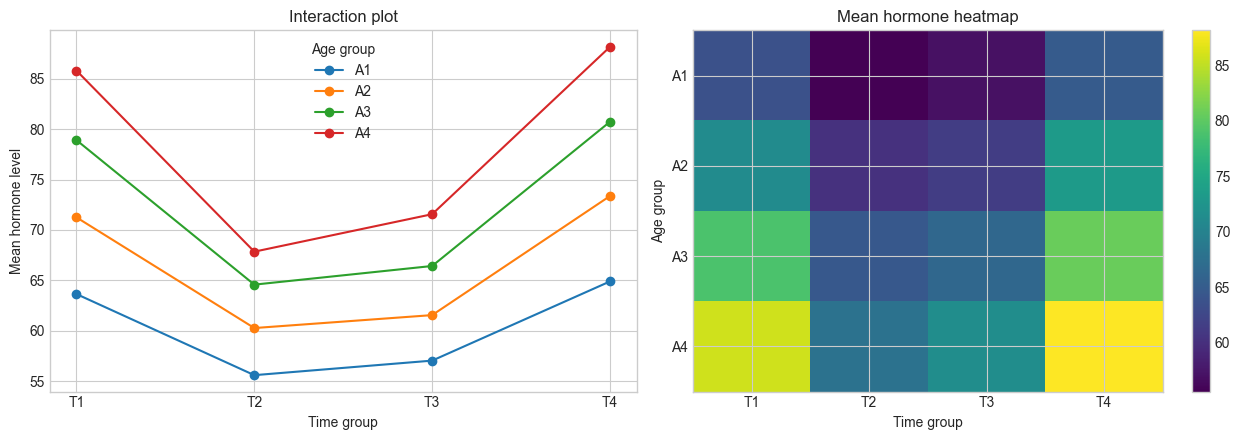

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for age_group in age_labels:
    axes[0].plot(time_labels, m_ij.loc[age_group], marker="o", label=age_group)
axes[0].set_title("Interaction plot")
axes[0].set_xlabel("Time group")
axes[0].set_ylabel("Mean hormone level")
axes[0].legend(title="Age group")

image = axes[1].imshow(m_ij.to_numpy(), aspect="auto", cmap="viridis")
axes[1].set_xticks(range(len(time_labels)))
axes[1].set_xticklabels(time_labels)
axes[1].set_yticks(range(len(age_labels)))
axes[1].set_yticklabels(age_labels)
axes[1].set_title("Mean hormone heatmap")
axes[1].set_xlabel("Time group")
axes[1].set_ylabel("Age group")
plt.colorbar(image, ax=axes[1])

plt.tight_layout()
plt.show()

In [14]:
tukey_age = pairwise_tukeyhsd(hormones["hormone_level"], hormones["age_group"], alpha=0.05)
tukey_time = pairwise_tukeyhsd(hormones["hormone_level"], hormones["time_group"], alpha=0.05)

tukey_age_table = pd.DataFrame(tukey_age.summary().data[1:], columns=tukey_age.summary().data[0])
tukey_time_table = pd.DataFrame(tukey_time.summary().data[1:], columns=tukey_time.summary().data[0])

tukey_age_table, tukey_time_table

(  group1 group2  meandiff  p-adj   lower   upper  reject
 0     A1     A2    6.1208 0.0000  5.4131  6.8284    True
 1     A1     A3   12.5820 0.0000 11.8810 13.2830    True
 2     A1     A4   18.2546 0.0000 17.5320 18.9772    True
 3     A2     A3    6.4612 0.0000  5.7465  7.1759    True
 4     A2     A4   12.1338 0.0000 11.3979 12.8698    True
 5     A3     A4    5.6726 0.0000  4.9431  6.4021    True,
   group1 group2  meandiff  p-adj    lower    upper  reject
 0     T1     T2  -12.7092 0.0000 -13.4451 -11.9733    True
 1     T1     T3  -10.6362 0.0000 -11.3644  -9.9080    True
 2     T1     T4    1.7303 0.0000   0.9997   2.4610    True
 3     T2     T3    2.0730 0.0000   1.2991   2.8469    True
 4     T2     T4   14.4395 0.0000  13.6634  15.2157    True
 5     T3     T4   12.3665 0.0000  11.5976  13.1354    True)

Вывод: значимы возраст, время измерения и взаимодействие. Значит, профиль гормона меняется не только по возрасту и времени отдельно, но и по их совместной комбинации.